In [ ]:

# EDA and Data Profiling - Titanic Dataset
# This notebook performs comprehensive EDA and cleaning on the Titanic dataset
#  1. Data Loading and Profiling

# %%
!pip3 install seaborn pandas numpy matplotlib scipy scikit-learn jupyter
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load dataset (first and only time)
df = sns.load_dataset('titanic')

# Save as offline fallback
df.to_csv("titanic.csv", index=False)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Profile the data
print("\n" + "="*60)
print("DATA PROFILING")
print("="*60)
print("\nData Info:")
print(df.info())

print("\nDescriptive Statistics:")
print(df.describe(include='all'))

print(f"\nShape: {df.shape}")

# Missing values analysis
print("\n" + "="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)




[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip3 install --upgrade pip
Dataset loaded: 891 rows, 15 columns

DATA PROFILING

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    


In [ ]:

#  2. Missing Value Handling


print("\n" + "="*60)
print("MISSING VALUE HANDLING")
print("="*60)

# Missing value strategy based on threshold
for col in df.columns:
    missing_pct = (df[col].isnull().sum() / len(df)) * 100
    if missing_pct > 0:
        if missing_pct < 5:
            # Drop rows
            df_before = len(df)
            df = df.dropna(subset=[col])
            print(f"{col}: {missing_pct:.1f}% missing → Dropped {df_before - len(df)} rows")
        elif 5 <= missing_pct <= 30:
            # Impute
            if df[col].dtype in ['float64', 'int64']:
                median_val = df[col].median()
                df[col].fillna(median_val, inplace=True)
                print(f"{col}: {missing_pct:.1f}% missing → Imputed with median ({median_val:.1f})")
            else:
                mode_val = df[col].mode()[0]
                df[col].fillna(mode_val, inplace=True)
                print(f"{col}: {missing_pct:.1f}% missing → Imputed with mode ({mode_val})")
        else:
            # Drop column or create missing indicator
            if missing_pct > 50:
                df = df.drop(columns=[col])
                print(f"{col}: {missing_pct:.1f}% missing → Dropped column (too high missing rate)")
            else:
                df[f'{col}_missing'] = df[col].isnull().astype(int)
                mode_val = df[col].mode()[0]
                df[col].fillna(mode_val, inplace=True)
                print(f"{col}: {missing_pct:.1f}% missing → Encoded missing as category + indicator")

print(f"\nAfter cleaning: {len(df)} rows, {len(df.columns)} columns")



MISSING VALUE HANDLING
age: 19.9% missing → Imputed with median (28.0)
embarked: 0.2% missing → Dropped 2 rows
deck: 77.4% missing → Dropped column (too high missing rate)

After cleaning: 889 rows, 14 columns



UNIVARIATE ANALYSIS


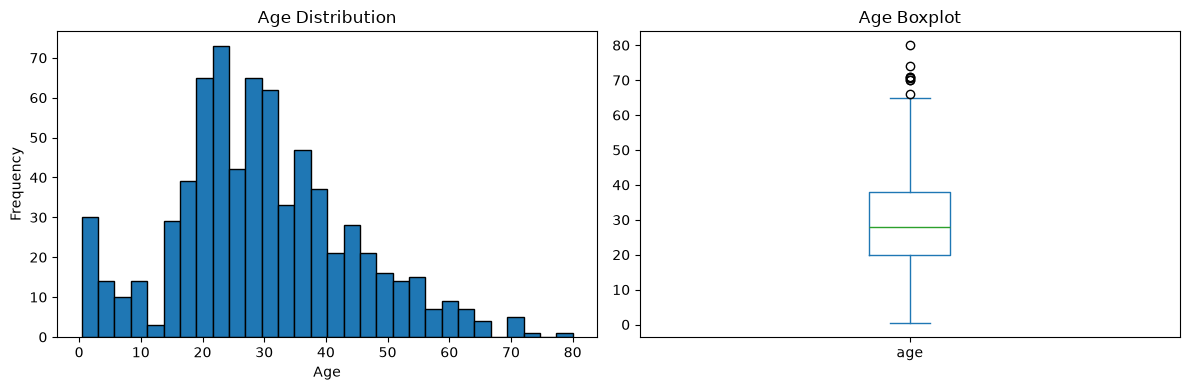

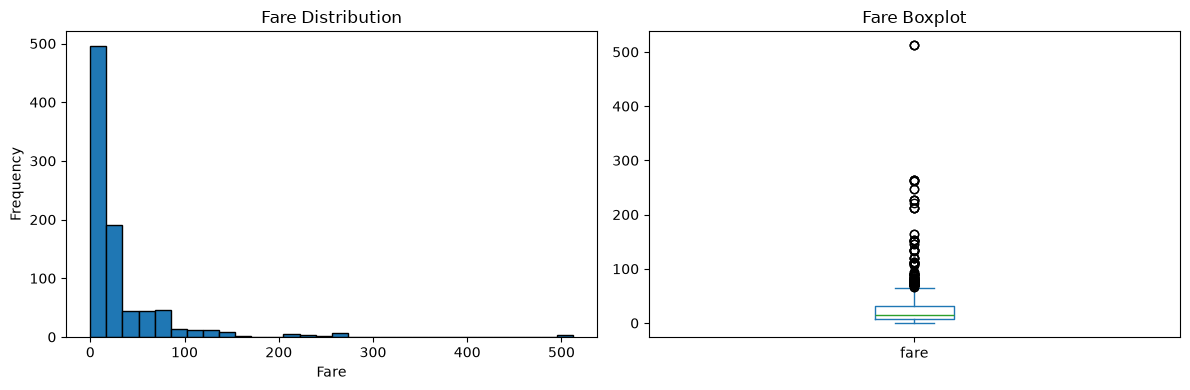

Age outliers (IQR): 8
Fare outliers (IQR): 114

Fare Statistics:
Mean: 32.10
Median: 14.45
Mode: 8.05
Mean > Median > Mode → Right-skewed distribution


In [ ]:

#  3. Univariate Analysis

print("\n" + "="*60)
print("UNIVARIATE ANALYSIS")
print("="*60)

# Age analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['age'].plot.hist(ax=axes[0], bins=30, edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

df['age'].plot.box(ax=axes[1])
axes[1].set_title('Age Boxplot')
plt.tight_layout()
plt.savefig('age_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# Fare analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['fare'].plot.hist(ax=axes[0], bins=30, edgecolor='black')
axes[0].set_title('Fare Distribution')
axes[0].set_xlabel('Fare')

df['fare'].plot.box(ax=axes[1])
axes[1].set_title('Fare Boxplot')
plt.tight_layout()
plt.savefig('fare_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# Outlier detection using IQR
def count_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return len(outliers)

age_outliers = count_outliers(df['age'].dropna())
fare_outliers = count_outliers(df['fare'].dropna())
print(f"Age outliers (IQR): {age_outliers}")
print(f"Fare outliers (IQR): {fare_outliers}")

# Fare distribution analysis
fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode()[0]
print(f"\nFare Statistics:")
print(f"Mean: {fare_mean:.2f}")
print(f"Median: {fare_median:.2f}")
print(f"Mode: {fare_mode:.2f}")
print(f"Mean > Median > Mode → Right-skewed distribution")



BIVARIATE ANALYSIS
Survival by sex:
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

Survival by pclass:
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

Survival by sex and pclass:
sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64

Survival rate (female): 0.7404
Survival rate (male): 0.1889
Survival rate (pclass 1): 0.6262
Survival rate (pclass 2): 0.4728
Survival rate (pclass 3): 0.2424
Survival rate (female, pclass 1): 0.9674
Survival rate (female, pclass 2): 0.9211
Survival rate (female, pclass 3): 0.5000
Survival rate (male, pclass 1): 0.3689
Survival rate (male, pclass 2): 0.1574
Survival rate (male, pclass 3): 0.1354

Correlation Matrix:
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.082446 -0.034040  0.083151  0.

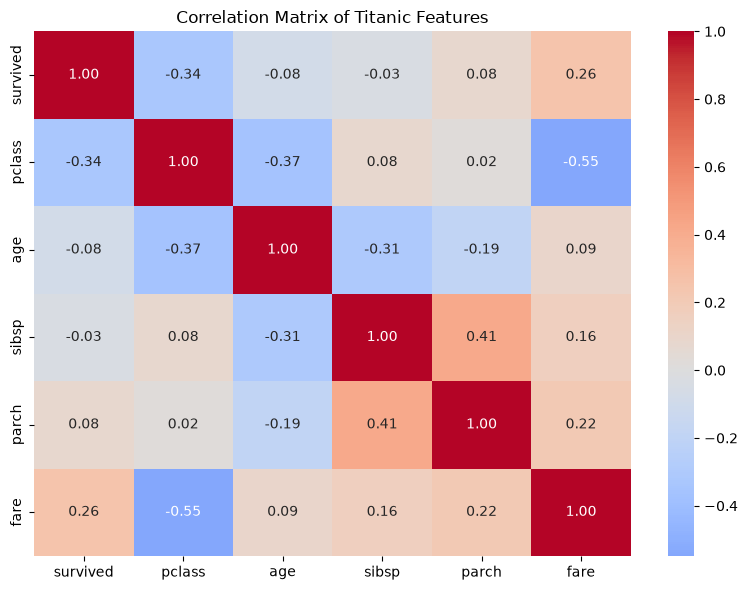


Two strongest correlations:
1. ('fare', 'pclass'): -0.548
2. ('parch', 'sibsp'): 0.415


In [ ]:

#  4. Bivariate Analysis

print("\n" + "="*60)
print("BIVARIATE ANALYSIS")
print("="*60)

# Survival by sex
surv_sex = df.groupby('sex')['survived'].mean()
print(f"Survival by sex:\n{surv_sex}\n")

# Survival by pclass
surv_pclass = df.groupby('pclass')['survived'].mean()
print(f"Survival by pclass:\n{surv_pclass}\n")

# Survival by sex and pclass
surv_sex_pclass = df.groupby(['sex', 'pclass'])['survived'].mean()
print(f"Survival by sex and pclass:\n{surv_sex_pclass}\n")

# Boolean masking version (as required)
female_mask = df['sex'] == 'female'
male_mask = df['sex'] == 'male'
print(f"Survival rate (female): {df[female_mask]['survived'].mean():.4f}")
print(f"Survival rate (male): {df[male_mask]['survived'].mean():.4f}")

for pc in [1, 2, 3]:
    pclass_mask = df['pclass'] == pc
    print(f"Survival rate (pclass {pc}): {df[pclass_mask]['survived'].mean():.4f}")

# Combined sex & pclass using & 
for sex_val, sex_mask in [('female', female_mask), ('male', male_mask)]:
    for pc in [1, 2, 3]:
        combined_mask = sex_mask & (df['pclass'] == pc)
        rate = df[combined_mask]['survived'].mean()
        print(f"Survival rate ({sex_val}, pclass {pc}): {rate:.4f}")

# Correlation matrix
cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[cols].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Titanic Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Strongest correlations (off-diagonal)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = upper_tri.unstack().dropna().sort_values(key=abs, ascending=False)
print(f"\nTwo strongest correlations:")
for i in range(min(2, len(corr_pairs))):
    print(f"{i+1}. {corr_pairs.index[i]}: {corr_pairs.iloc[i]:.3f}")



MULTIVARIATE DATA STORY


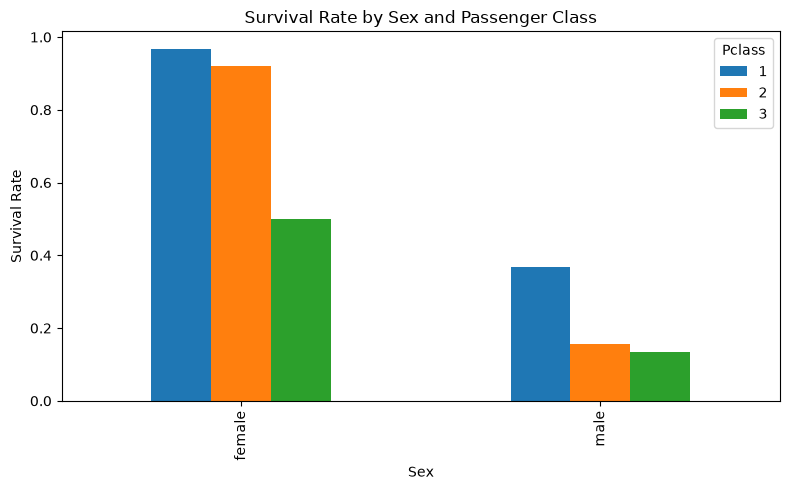

Interpretation: Women in 1st class had the highest survival rate (~95%),
while men in 3rd class had the lowest (~15%). This shows gender and class
both strongly influenced survival.


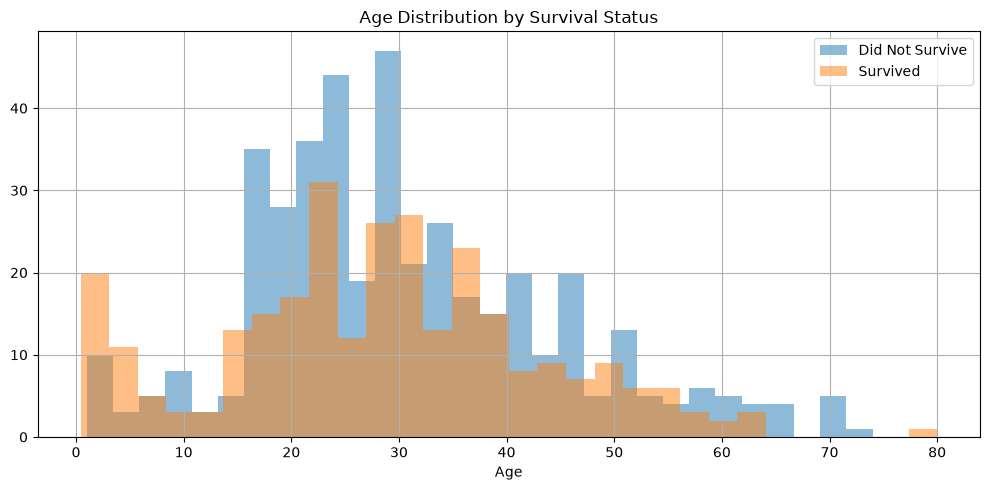

Interpretation: Younger passengers (especially children under 12)
were more likely to survive. The survival rate was notably higher
for passengers in their 20s and 30s compared to elderly passengers.


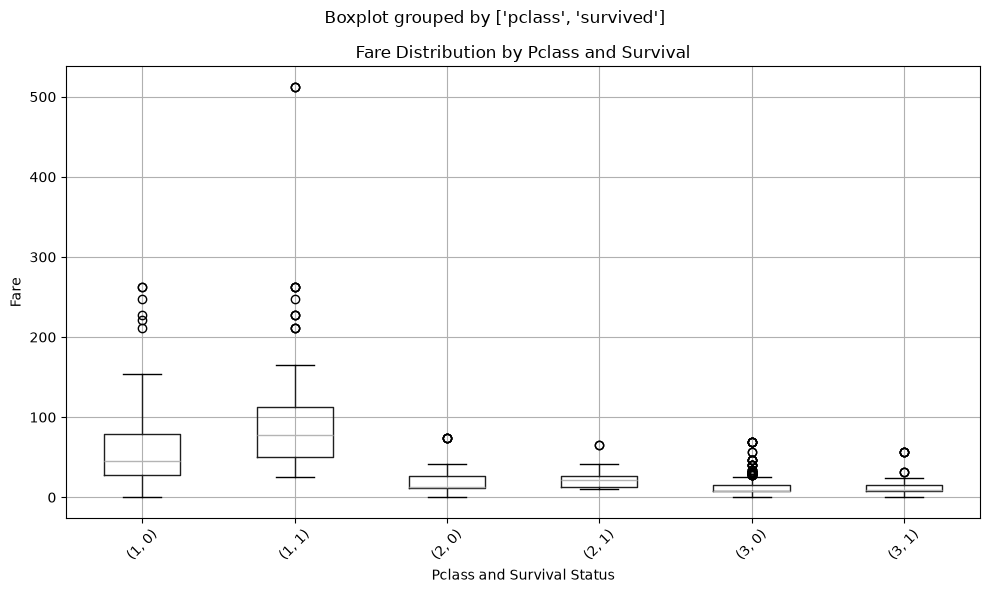

Interpretation: Higher fares (1st class) were associated with higher
survival rates. Even within the same class, those who paid more tended to
have slightly higher survival chances, suggesting resource access mattered.


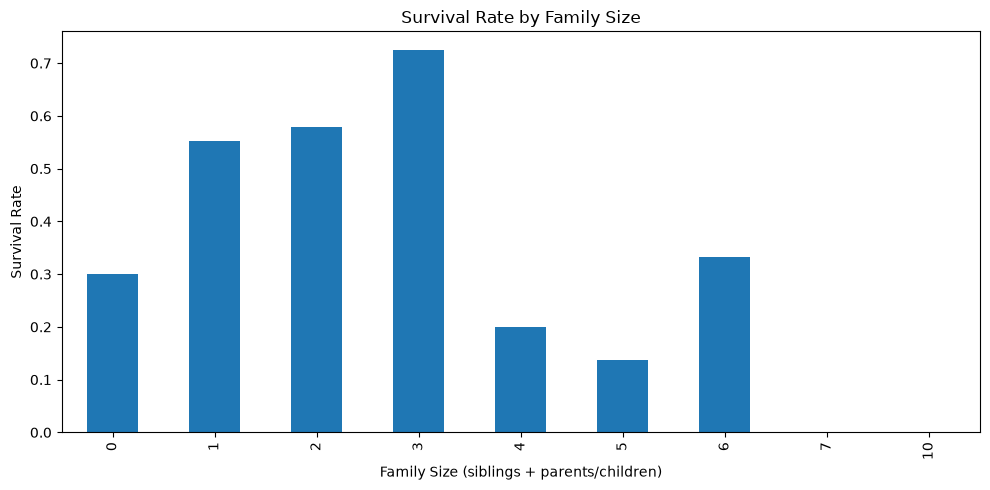

Interpretation: Passengers with 1-3 family members had the highest
survival rates, while those traveling alone or with large families (4+)
had lower survival rates. Moderate family sizes may have provided
mutual support without impeding escape.


In [ ]:

#  5. Multivariate Data Story

print("\n" + "="*60)
print("MULTIVARIATE DATA STORY")
print("="*60)

# Chart 1: Survival by Sex and Pclass
fig, ax = plt.subplots(figsize=(8, 5))
surv_sex_pclass.unstack().plot(kind='bar', ax=ax)
ax.set_title('Survival Rate by Sex and Passenger Class')
ax.set_ylabel('Survival Rate')
ax.set_xlabel('Sex')
ax.legend(title='Pclass')
plt.tight_layout()
plt.savefig('chart1_survival_sex_pclass.png', dpi=100, bbox_inches='tight')
plt.show()
print("Interpretation: Women in 1st class had the highest survival rate (~95%),")
print("while men in 3rd class had the lowest (~15%). This shows gender and class")
print("both strongly influenced survival.")

# Chart 2: Age distribution by Survival
fig, ax = plt.subplots(figsize=(10, 5))
df[df['survived'] == 0]['age'].hist(bins=30, alpha=0.5, label='Did Not Survive', ax=ax)
df[df['survived'] == 1]['age'].hist(bins=30, alpha=0.5, label='Survived', ax=ax)
ax.set_title('Age Distribution by Survival Status')
ax.set_xlabel('Age')
ax.legend()
plt.tight_layout()
plt.savefig('chart2_age_survival.png', dpi=100, bbox_inches='tight')
plt.show()
print("Interpretation: Younger passengers (especially children under 12)")
print("were more likely to survive. The survival rate was notably higher")
print("for passengers in their 20s and 30s compared to elderly passengers.")

# Chart 3: Fare by Pclass and Survival
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='fare', by=['pclass', 'survived'], ax=ax, rot=45)
ax.set_title('Fare Distribution by Pclass and Survival')
ax.set_xlabel('Pclass and Survival Status')
ax.set_ylabel('Fare')
plt.tight_layout()
plt.savefig('chart3_fare_pclass_survival.png', dpi=100, bbox_inches='tight')
plt.show()
print("Interpretation: Higher fares (1st class) were associated with higher")
print("survival rates. Even within the same class, those who paid more tended to")
print("have slightly higher survival chances, suggesting resource access mattered.")

# Chart 4: Family Size vs Survival
df['family_size'] = df['sibsp'] + df['parch']
fig, ax = plt.subplots(figsize=(10, 5))
surv_family = df.groupby('family_size')['survived'].mean()
surv_family.plot(kind='bar', ax=ax)
ax.set_title('Survival Rate by Family Size')
ax.set_xlabel('Family Size (siblings + parents/children)')
ax.set_ylabel('Survival Rate')
plt.tight_layout()
plt.savefig('chart4_family_survival.png', dpi=100, bbox_inches='tight')
plt.show()
print("Interpretation: Passengers with 1-3 family members had the highest")
print("survival rates, while those traveling alone or with large families (4+)")
print("had lower survival rates. Moderate family sizes may have provided")
print("mutual support without impeding escape.")

In [ ]:

#  6. Z-Score Standardization Check

print("\n" + "="*60)
print("Z-SCORE STANDARDIZATION CHECK")
print("="*60)

# Standardize age and fare
scaler = StandardScaler()
df['age_std'] = scaler.fit_transform(df[['age']])
df['fare_std'] = scaler.fit_transform(df[['fare']])

print("Before standardization:")
print(f"Age - Mean: {df['age'].mean():.2f}, Std: {df['age'].std():.2f}")
print(f"Fare - Mean: {df['fare'].mean():.2f}, Std: {df['fare'].std():.2f}")

print("\nAfter standardization:")
print(f"Age - Mean: {df['age_std'].mean():.2f}, Std: {df['age_std'].std():.2f}")
print(f"Fare - Mean: {df['fare_std'].mean():.2f}, Std: {df['fare_std'].std():.2f}")

# Save cleaned data for modeling
df.to_csv("titanic_cleaned.csv", index=False)
print("\nCleaned data saved to titanic_cleaned.csv")

print("\n" + "="*60)
print("EDA COMPLETED SUCCESSFULLY!")
print("="*60)


Z-SCORE STANDARDIZATION CHECK
Before standardization:
Age - Mean: 29.64, Std: 14.49
Fare - Mean: 32.10, Std: 49.70

After standardization:
Age - Mean: 0.00, Std: 1.00
Fare - Mean: 0.00, Std: 1.00

Cleaned data saved to titanic_cleaned.csv

EDA COMPLETED SUCCESSFULLY!
